<a href="https://colab.research.google.com/github/tranxuantruongworld/M-foudation-in-math/blob/main/matrix_factorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Component 1: Mean Centering
**Yêu cầu:** Hoàn thành hàm `center_data(X)`.
- Input: Ma trận `X` (n, m).
- Output: Ma trận `X_centered` cùng kích thước nhưng có trung bình mỗi cột bằng 0.

In [ ]:
import numpy as np

def center_data(X):
    # Gợi ý: Sử dụng np.mean với axis=0
    # TỰ CODE TẠI ĐÂY
    x_center =  np.mean(X, axis=0)
    return X - x_center

# --- TEST CASE ---
X_test = np.array([[1, 2], [3, 4], [5, 6]])
X_centered_test = center_data(X_test)
if X_centered_test is not None:
    column_means = np.mean(X_centered_test, axis=0)
    print(f"Trung bình sau khi centering: {column_means}")
    assert np.allclose(column_means, [0, 0]), "Lỗi: Trung bình các cột chưa bằng 0!"

Trung bình sau khi centering: [0. 0.]


### Component 2: Covariance Matrix
**Yêu cầu:** Hoàn thành hàm `compute_covariance(X_centered)`.
- Input: Ma trận đã centering.
- Output: Ma trận vuông (m, m) thể hiện hiệp phương sai.
- **Lưu ý:** Không dùng `np.cov`, hãy dùng toán tử `@` hoặc `np.dot`.

In [ ]:
def compute_covariance(X_centered):
    n = X_centered.shape[0]
    print(X_centered.T)
    return X_centered.T @ X_centered / (n-1)

# --- TEST CASE ---
# Giả sử X_centered_test đã chạy đúng ở trên
cov_test = compute_covariance(X_centered_test)
if cov_test is not None:
    print(f"Ma trận hiệp phương sai:\n{cov_test}")
    # Kiểm tra tính đối xứng của ma trận
    assert np.allclose(cov_test, cov_test.T), "Lỗi: Ma trận hiệp phương sai phải đối xứng!"

[[-2.  0.  2.]
 [-2.  0.  2.]]
Ma trận hiệp phương sai:
[[4. 4.]
 [4. 4.]]


### Component 3: Eigen-decomposition & Projection
**Yêu cầu:** Hoàn thành bước cuối cùng để lấy kết quả PCA.
- Input: `X_centered`, `cov_matrix`, và số chiều `k`.
- Output: Dữ liệu mới đã giảm chiều.

In [ ]:
def project_data(X_centered, cov_matrix, k=1):
    # 1. Tính eigenvalues/eigenvectors bằng np.linalg.eig
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # 2. Sắp xếp indices của eigenvalues giảm dần
    idx = np.argsort(eigenvalues)[::-1]

    # 3. Lấy k eigenvectors tốt nhất
    top_eigenvectors = eigenvectors[:, idx[:k]]
    # 4. Chiếu dữ liệu bằng phép nhân ma trận
    X_pca = X_centered @ top_eigenvectors
    return X_pca

# --- TEST CASE ---
# Thử chạy với X_test ban đầu (3 mẫu, 2 đặc trưng) xuống còn 1 đặc trưng
result = project_data(X_centered_test, cov_test, k=1)
# if result is not None: print("Shape sau PCA:", result.shape)

In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Thiết lập số lượng người dùng và phim
num_users = 50
num_movies = 100

# Tạo ma trận đánh giá ngẫu nhiên với các giá trị từ 1 đến 5
# Giả lập ma trận thưa bằng cách gán NaN cho một phần lớn các ô
np.random.seed(42)
ratings = np.random.randint(1, 6, size=(num_users, num_movies)).astype(float)

# Giới thiệu các giá trị NaN để làm cho ma trận thưa
# Ví dụ: 70% các giá trị sẽ là NaN
missing_ratio = 0.7
num_missing = int(num_users * num_movies * missing_ratio)
missing_indices = np.random.choice(num_users * num_movies, num_missing, replace=False)

flat_ratings = ratings.flatten()
flat_ratings[missing_indices] = np.nan
ratings = flat_ratings.reshape(num_users, num_movies)

# Chuyển đổi thành DataFrame để dễ quản lý
rating_matrix = pd.DataFrame(ratings, index=[f'User_{i+1}' for i in range(num_users)],
                           columns=[f'Movie_{j+1}' for j in range(num_movies)])

print("Ma trận đánh giá thưa:")
display(rating_matrix.head())
print(f"Số lượng giá trị NaN: {rating_matrix.isnull().sum().sum()}")

Ma trận đánh giá thưa:


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_91,Movie_92,Movie_93,Movie_94,Movie_95,Movie_96,Movie_97,Movie_98,Movie_99,Movie_100
User_1,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,2.0,5.0,4.0,2.0,4.0,NaN,NaN,NaN,5.0,NaN
User_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,5.0,3.0,4.0,NaN
User_4,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,5.0,NaN,...,1.0,5.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
User_5,NaN,5.0,NaN,NaN,4.0,NaN,NaN,4.0,NaN,4.0,...,1.0,5.0,NaN,NaN,5.0,1.0,NaN,1.0,1.0,NaN


Số lượng giá trị NaN: 3500


### 1. Tạo Dữ liệu Ma trận Đánh giá Phim Thưa

Để mô phỏng một ma trận đánh giá phim thực tế, chúng ta sẽ tạo một ma trận ngẫu nhiên với một số giá trị bị thiếu (NaN). Ma trận này sẽ có người dùng (user) là hàng và phim (item) là cột, với các giá trị từ 1 đến 5 đại diện cho điểm đánh giá.

In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Thiết lập số lượng người dùng và phim
num_users = 50
num_movies = 100

# Tạo ma trận đánh giá ngẫu nhiên với các giá trị từ 1 đến 5
# Giả lập ma trận thưa bằng cách gán NaN cho một phần lớn các ô
np.random.seed(42)
ratings = np.random.randint(1, 6, size=(num_users, num_movies)).astype(float)

# Giới thiệu các giá trị NaN để làm cho ma trận thưa
# Ví dụ: 70% các giá trị sẽ là NaN
missing_ratio = 0.7
num_missing = int(num_users * num_movies * missing_ratio)
missing_indices = np.random.choice(num_users * num_movies, num_missing, replace=False)

flat_ratings = ratings.flatten()
flat_ratings[missing_indices] = np.nan
ratings = flat_ratings.reshape(num_users, num_movies)

# Chuyển đổi thành DataFrame để dễ quản lý
rating_matrix = pd.DataFrame(ratings, index=[f'User_{i+1}' for i in range(num_users)],
                           columns=[f'Movie_{j+1}' for j in range(num_movies)])

print("Ma trận đánh giá thưa:")
display(rating_matrix.head())
print(f"Số lượng giá trị NaN: {rating_matrix.isnull().sum().sum()}")

Ma trận đánh giá thưa:


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_91,Movie_92,Movie_93,Movie_94,Movie_95,Movie_96,Movie_97,Movie_98,Movie_99,Movie_100
User_1,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,2.0,5.0,4.0,2.0,4.0,NaN,NaN,NaN,5.0,NaN
User_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,5.0,3.0,4.0,NaN
User_4,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,5.0,NaN,...,1.0,5.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
User_5,NaN,5.0,NaN,NaN,4.0,NaN,NaN,4.0,NaN,4.0,...,1.0,5.0,NaN,NaN,5.0,1.0,NaN,1.0,1.0,NaN


Số lượng giá trị NaN: 3500


### 2. Xử lý Dữ liệu và Áp dụng SVD

Để áp dụng SVD, chúng ta cần thay thế các giá trị `NaN` bằng 0. Sau đó, chúng ta sẽ chia dữ liệu thành tập huấn luyện và tập kiểm tra để đánh giá chất lượng dự đoán. SVD sẽ được sử dụng để phân tách ma trận thành ba ma trận con, từ đó chúng ta có thể tái tạo ma trận gốc với rank thấp hơn.

In [ ]:
# Tạo một bản sao của ma trận đánh giá để giữ nguyên các giá trị gốc
almost_original_ratings = rating_matrix.copy()

# Thay thế NaN bằng 0 cho SVD
ratings_filled_zero = rating_matrix.fillna(0).values

# Chuẩn bị dữ liệu cho việc đánh giá RMSE
# Chúng ta chỉ quan tâm đến các ô đã được đánh giá trong ma trận gốc
# Tách dữ liệu thành tập huấn luyện và kiểm tra

# Tìm các chỉ số của các rating đã biết
known_ratings_indices = np.where(~rating_matrix.isnull())

# Lấy các giá trị rating đã biết
known_ratings = rating_matrix.values[known_ratings_indices]

# Tách các chỉ số thành tập huấn luyện và kiểm tra
indices_train, indices_test = train_test_split(list(zip(*known_ratings_indices)), test_size=0.2, random_state=42)

# Tạo ma trận huấn luyện và kiểm tra thưa
ratings_train = np.full((num_users, num_movies), np.nan)
ratings_test = np.full((num_users, num_movies), np.nan)

for u, m in indices_train:
    ratings_train[u, m] = rating_matrix.iloc[u, m]

for u, m in indices_test:
    ratings_test[u, m] = rating_matrix.iloc[u, m]

print("Ma trận huấn luyện (có NaN):")
display(pd.DataFrame(ratings_train, index=rating_matrix.index, columns=rating_matrix.columns).head())
print("Ma trận kiểm tra (có NaN):")
display(pd.DataFrame(ratings_test, index=rating_matrix.index, columns=rating_matrix.columns).head())

Ma trận huấn luyện (có NaN):


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_91,Movie_92,Movie_93,Movie_94,Movie_95,Movie_96,Movie_97,Movie_98,Movie_99,Movie_100
User_1,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,2.0,5.0,4.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN
User_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,5.0,3.0,4.0,NaN
User_4,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,5.0,NaN,...,NaN,5.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
User_5,NaN,5.0,NaN,NaN,4.0,NaN,NaN,4.0,NaN,4.0,...,1.0,5.0,NaN,NaN,5.0,1.0,NaN,1.0,1.0,NaN


Ma trận kiểm tra (có NaN):


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_91,Movie_92,Movie_93,Movie_94,Movie_95,Movie_96,Movie_97,Movie_98,Movie_99,Movie_100
User_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN
User_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Khảo sát ảnh hưởng của Rank đến Chất lượng Dự đoán (RMSE)

Chúng ta sẽ định nghĩa một hàm để thực hiện SVD, dự đoán các giá trị còn thiếu, và tính toán RMSE trên tập kiểm tra. Sau đó, chúng ta sẽ lặp lại quá trình này với các giá trị `rank` khác nhau và vẽ biểu đồ kết quả.

Rank: 1, RMSE: 2.8522
Rank: 6, RMSE: 3.0127
Rank: 11, RMSE: 3.0932
Rank: 16, RMSE: 3.1888
Rank: 21, RMSE: 3.2748
Rank: 26, RMSE: 3.3568
Rank: 31, RMSE: 3.4065
Rank: 36, RMSE: 3.4236
Rank: 41, RMSE: 3.4354
Rank: 46, RMSE: 3.4412


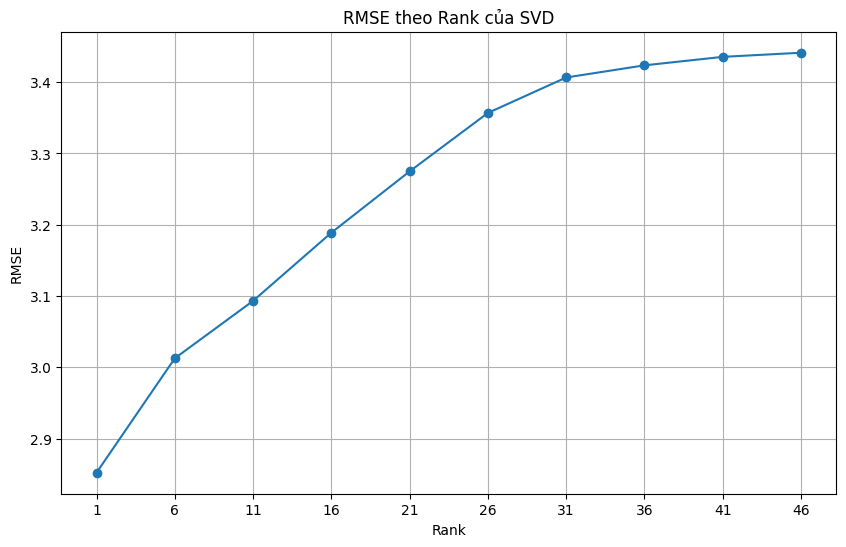

In [ ]:
def evaluate_svd_rank(train_matrix, test_matrix, rank):
    # Điền 0 vào các giá trị NaN trong ma trận huấn luyện cho SVD
    train_filled_zero = np.nan_to_num(train_matrix, nan=0.0)

    # Thực hiện SVD
    # svds từ scipy.sparse.linalg là tốt cho ma trận thưa
    U, sigma, Vt = svds(train_filled_zero, k=rank)

    # Chuyển đổi sigma thành ma trận đường chéo
    sigma_diag = np.diag(sigma)

    # Tái tạo ma trận dự đoán
    predicted_ratings = np.dot(np.dot(U, sigma_diag), Vt)

    # Chỉ tính RMSE trên các giá trị đã biết trong tập kiểm tra
    test_known_indices = np.where(~np.isnan(test_matrix))
    actual_ratings = test_matrix[test_known_indices]
    predicted_ratings_for_test = predicted_ratings[test_known_indices]

    # Tính RMSE
    rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings_for_test))
    return rmse, predicted_ratings

# Danh sách các rank để khảo sát
ranks_to_test = range(1, min(num_users, num_movies) - 1, 5)
if len(ranks_to_test) == 0: # Ensure at least one rank is tested if min(num_users, num_movies) is small
    ranks_to_test = [1]
elif ranks_to_test[0] == 0:
    ranks_to_test = ranks_to_test[1:] # Rank must be > 0

rmse_scores = []

for r in ranks_to_test:
    rmse, _ = evaluate_svd_rank(ratings_train, ratings_test, r)
    rmse_scores.append(rmse)
    print(f"Rank: {r}, RMSE: {rmse:.4f}")

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
plt.plot(ranks_to_test, rmse_scores, marker='o')
plt.title('RMSE theo Rank của SVD')
plt.xlabel('Rank')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(ranks_to_test)
plt.show()

### 4. Gợi ý Phim

Sau khi đã xác định được rank tối ưu (hoặc một rank hợp lý), chúng ta sẽ sử dụng SVD với rank đó để dự đoán toàn bộ ma trận đánh giá. Sau đó, dựa vào ma trận dự đoán này, chúng ta có thể gợi ý phim cho người dùng.

In [ ]:
# Chọn một rank tối ưu (ví dụ: rank có RMSE thấp nhất, hoặc một giá trị hợp lý khác từ biểu đồ)
optimal_rank_index = np.argmin(rmse_scores)
optimal_rank = ranks_to_test[optimal_rank_index]
print(f"Rank tối ưu được chọn dựa trên RMSE thấp nhất: {optimal_rank}")

# Sử dụng rank tối ưu để tái tạo toàn bộ ma trận (dự đoán các giá trị bị thiếu)
# Điền 0 vào các giá trị NaN trong ma trận gốc để thực hiện SVD
full_ratings_filled_zero = np.nan_to_num(rating_matrix.values, nan=0.0)

U_full, sigma_full, Vt_full = svds(full_ratings_filled_zero, k=optimal_rank)
sigma_diag_full = np.diag(sigma_full)

predicted_full_ratings = np.dot(np.dot(U_full, sigma_diag_full), Vt_full)
predicted_full_df = pd.DataFrame(predicted_full_ratings, index=rating_matrix.index, columns=rating_matrix.columns)

print("Ma trận đánh giá được dự đoán (5 hàng đầu tiên):")
display(predicted_full_df.head())

# Hàm gợi ý phim cho một người dùng cụ thể
def recommend_movies(user_id, original_rating_df, predicted_rating_df, num_recommendations=5):
    user_idx = original_rating_df.index.get_loc(user_id)

    # Lấy các phim mà người dùng đã đánh giá
    watched_movies = original_rating_df.loc[user_id][original_rating_df.loc[user_id].notna()].index

    # Lấy tất cả các dự đoán cho người dùng này
    user_predictions = predicted_rating_df.loc[user_id]

    # Loại bỏ các phim đã xem khỏi danh sách gợi ý
    unwatched_movies_predictions = user_predictions.drop(watched_movies, errors='ignore')

    # Sắp xếp các phim chưa xem theo điểm dự đoán giảm dần
    top_recommendations = unwatched_movies_predictions.sort_values(ascending=False).head(num_recommendations)

    return top_recommendations

# Gợi ý phim cho 'User_1'
user_to_recommend = 'User_1'
recommendations = recommend_movies(user_to_recommend, rating_matrix, predicted_full_df)

print(f"\nTop {len(recommendations)} phim gợi ý cho {user_to_recommend}:")
print(recommendations)

Rank tối ưu được chọn dựa trên RMSE thấp nhất: 1
Ma trận đánh giá được dự đoán (5 hàng đầu tiên):


,Movie_1,Movie_2,Movie_3,Movie_4,Movie_5,Movie_6,Movie_7,Movie_8,Movie_9,Movie_10,...,Movie_91,Movie_92,Movie_93,Movie_94,Movie_95,Movie_96,Movie_97,Movie_98,Movie_99,Movie_100
User_1,0.510010,0.627497,0.528809,0.723764,0.545777,0.800130,0.675417,0.643035,0.693800,0.780791,...,0.782024,0.766204,0.726272,0.506565,0.626768,0.546828,0.560085,0.679010,1.004274,0.646580
User_2,0.831858,1.023485,0.862519,1.180502,0.890195,1.305060,1.101646,1.048829,1.131629,1.273517,...,1.275529,1.249725,1.184593,0.826238,1.022297,0.891910,0.913533,1.107506,1.638031,1.054611
User_3,0.647164,0.796245,0.671018,0.918401,0.692549,1.015304,0.857052,0.815962,0.880378,0.990764,...,0.992329,0.972254,0.921583,0.642792,0.795321,0.693883,0.710705,0.861612,1.274346,0.820460
User_4,0.635552,0.781958,0.658977,0.901921,0.680122,0.997085,0.841674,0.801321,0.864581,0.972986,...,0.974523,0.954809,0.905047,0.631258,0.781050,0.681432,0.697953,0.846151,1.251480,0.805738
User_5,0.798679,0.982663,0.828118,1.133418,0.854690,1.253008,1.057707,1.006996,1.086494,1.222723,...,1.224654,1.199880,1.137346,0.793284,0.981523,0.856336,0.877096,1.063333,1.572698,1.012547



Top 5 phim gợi ý cho User_1:
Movie_82    1.029018
Movie_72    1.021402
Movie_99    1.004274
Movie_32    0.991592
Movie_60    0.984415
Name: User_1, dtype: float64


### 5. Áp dụng với Dataset thực tế: MovieLens 100k

Chúng ta sẽ tải tập dữ liệu MovieLens 100k gồm 100,000 đánh giá từ 943 người dùng cho 1,682 bộ phim.

In [4]:
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds

# Tải dữ liệu ratings
ratings_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
columns = ['user_id', 'item_id', 'rating', 'timestamp']
real_df = pd.read_csv(ratings_url, sep='\t', names=columns)

# Tải thông tin phim (để lấy tên phim thay vì ID)
items_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'
item_columns = ['item_id', 'movie_title'] + [str(i) for i in range(22)] # Chỉ lấy 2 cột đầu
movies_df = pd.read_csv(items_url, sep='|', names=item_columns, encoding='latin-1')[['item_id', 'movie_title']]

# Tạo ma trận user-item thực tế
real_matrix_df = real_df.pivot(index='user_id', columns='item_id', values='rating')

print(f"Kích thước ma trận thực tế: {real_matrix_df.shape}")
display(real_matrix_df.head())

# Điền 0 và thực hiện SVD với rank k=50 (một giá trị phổ biến cho ML-100k)
R = real_matrix_df.fillna(0).values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

U, sigma, Vt = svds(R_demeaned, k=50)
sigma = np.diag(sigma)

# Tái tạo ma trận dự đoán và cộng lại giá trị trung bình
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
preds_df = pd.DataFrame(all_user_predicted_ratings, columns=real_matrix_df.columns, index=real_matrix_df.index)

print("Đã hoàn thành tính toán SVD cho MovieLens!")

Kích thước ma trận thực tế: (943, 1682)


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Đã hoàn thành tính toán SVD cho MovieLens!


### 6. Khảo sát ảnh hưởng của Rank đến Chất lượng Dự đoán (RMSE) cho MovieLens 100k

Chúng ta sẽ áp dụng cùng phương pháp như với bộ dữ liệu tổng hợp để khảo sát giá trị rank tối ưu cho MovieLens 100k.

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Bước 1: Chuẩn bị dữ liệu huấn luyện và kiểm tra cho MovieLens 100k

# Tìm các chỉ số của các rating đã biết trong ma trận thực tế
known_ratings_indices_real = np.where(~real_matrix_df.isnull())

# Lấy các giá trị rating đã biết
known_ratings_real = real_matrix_df.values[known_ratings_indices_real]

# Tách các chỉ số thành tập huấn luyện và kiểm tra
indices_train_real, indices_test_real = train_test_split(
    list(zip(*known_ratings_indices_real)), test_size=0.2, random_state=42)

# Tạo ma trận huấn luyện và kiểm tra thưa cho MovieLens
real_ratings_train = np.full(real_matrix_df.shape, np.nan)
real_ratings_test = np.full(real_matrix_df.shape, np.nan)

for u, m in indices_train_real:
    real_ratings_train[u, m] = real_matrix_df.iloc[u, m]

for u, m in indices_test_real:
    real_ratings_test[u, m] = real_matrix_df.iloc[u, m]

print("Ma trận huấn luyện MovieLens (có NaN):")
display(pd.DataFrame(real_ratings_train, index=real_matrix_df.index, columns=real_matrix_df.columns).head())
print("Ma trận kiểm tra MovieLens (có NaN):")
display(pd.DataFrame(real_ratings_test, index=real_matrix_df.index, columns=real_matrix_df.columns).head())

Ma trận huấn luyện MovieLens (có NaN):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ma trận kiểm tra MovieLens (có NaN):


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
import numpy as np
import time # Import the time module
import pandas as pd # Import pandas for DataFrame

def evaluate_svd_rank_movielens(train_matrix, test_matrix, rank):
    # Điền 0 vào các giá trị NaN trong ma trận huấn luyện cho SVD
    train_filled_zero = np.nan_to_num(train_matrix, nan=0.0)

    # Tính toán trung bình của người dùng từ dữ liệu huấn luyện (chỉ các giá trị đã biết)
    user_ratings_mean_train = np.array([np.nanmean(row) if not np.all(np.isnan(row)) else 0 for row in train_matrix])

    # Áp dụng demean cho ma trận huấn luyện đã điền 0
    R_demeaned_train = train_filled_zero - user_ratings_mean_train.reshape(-1, 1)

    # Thực hiện SVD
    U, sigma, Vt = svds(R_demeaned_train, k=rank)

    # Chuyển đổi sigma thành ma trận đường chéo
    sigma_diag = np.diag(sigma)

    # Tái tạo ma trận dự đoán và cộng lại giá trị trung bình
    predicted_ratings = np.dot(np.dot(U, sigma_diag), Vt) + user_ratings_mean_train.reshape(-1, 1)

    # Tính RMSE trên tập huấn luyện
    train_known_indices = np.where(~np.isnan(train_matrix))
    actual_train_ratings = train_matrix[train_known_indices]
    predicted_train_ratings = predicted_ratings[train_known_indices]
    rmse_train = np.sqrt(mean_squared_error(actual_train_ratings, predicted_train_ratings))

    # Tính RMSE trên các giá trị đã biết trong tập kiểm tra
    test_known_indices = np.where(~np.isnan(test_matrix))
    actual_test_ratings = test_matrix[test_known_indices]
    predicted_test_ratings = predicted_ratings[test_known_indices]
    rmse_test = np.sqrt(mean_squared_error(actual_test_ratings, predicted_test_ratings))

    return rmse_train, rmse_test, predicted_ratings

# Danh sách các rank để khảo sát cho MovieLens
ranks_to_test_movielens = range(1, 100, 10)

results_movielens = []

print("Bắt đầu khảo sát ảnh hưởng của Rank đến RMSE và Thời gian cho MovieLens 100k:")
for r in ranks_to_test_movielens:
    start_time = time.time()
    rmse_train, rmse_test, _ = evaluate_svd_rank_movielens(real_ratings_train, real_ratings_test, r)
    end_time = time.time()
    duration = end_time - start_time
    results_movielens.append({'Rank': r, 'RMSE (Train)': rmse_train, 'RMSE (Test)': rmse_test, 'Thời gian (s)': duration})
    print(f"Rank: {r}, RMSE (Train): {rmse_train:.4f}, RMSE (Test): {rmse_test:.4f}, Thời gian: {duration:.4f}s")

results_df_movielens = pd.DataFrame(results_movielens)
print("\nBảng kết quả:")
display(results_df_movielens)


Bắt đầu khảo sát ảnh hưởng của Rank đến RMSE và Thời gian cho MovieLens 100k:
Rank: 1, RMSE (Train): 3.0836, RMSE (Test): 3.0958, Thời gian: 0.3051s
Rank: 11, RMSE (Train): 2.4608, RMSE (Test): 2.6150, Thời gian: 0.8744s
Rank: 21, RMSE (Train): 2.3211, RMSE (Test): 2.6530, Thời gian: 0.3653s
Rank: 31, RMSE (Train): 2.2106, RMSE (Test): 2.7339, Thời gian: 0.5241s
Rank: 41, RMSE (Train): 2.1118, RMSE (Test): 2.8181, Thời gian: 0.4933s
Rank: 51, RMSE (Train): 2.0187, RMSE (Test): 2.8975, Thời gian: 0.4617s
Rank: 61, RMSE (Train): 1.9320, RMSE (Test): 2.9650, Thời gian: 0.5646s
Rank: 71, RMSE (Train): 1.8503, RMSE (Test): 3.0330, Thời gian: 0.5319s
Rank: 81, RMSE (Train): 1.7716, RMSE (Test): 3.0881, Thời gian: 0.9090s
Rank: 91, RMSE (Train): 1.6972, RMSE (Test): 3.1400, Thời gian: 0.9040s

Bảng kết quả:


,Rank,RMSE (Train),RMSE (Test),Thời gian (s)
0,1,3.083641,3.095780,0.305137
1,11,2.460795,2.614969,0.874438
2,21,2.321062,2.653012,0.365312
3,31,2.210632,2.733850,0.524106
4,41,2.111762,2.818112,0.493283
5,51,2.018737,2.897524,0.461689
6,61,1.932002,2.964962,0.564628
7,71,1.850333,3.033001,0.531869
8,81,1.771553,3.088144,0.909049
9,91,1.697227,3.139992,0.903962


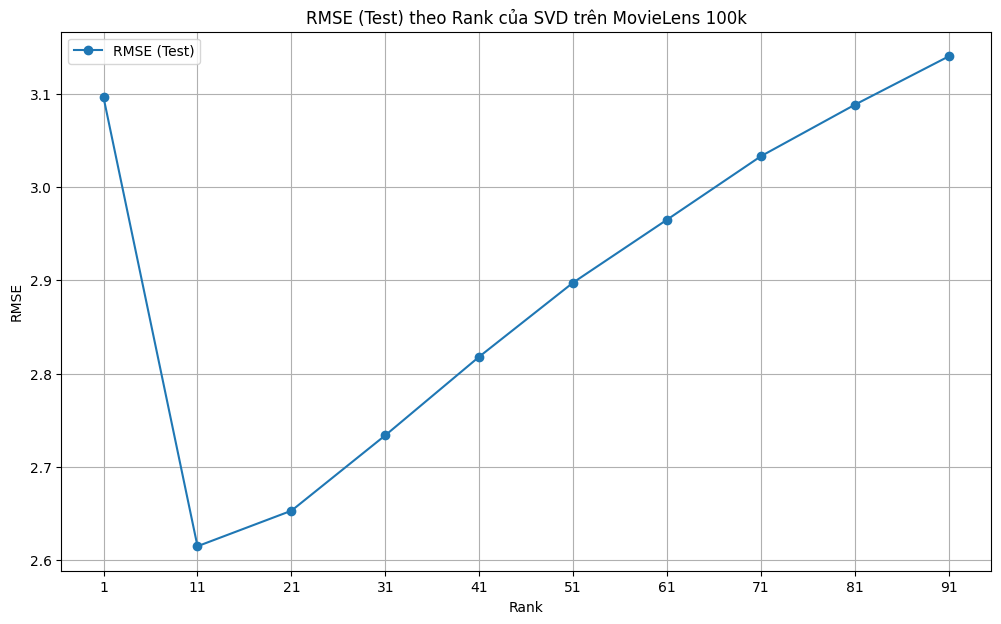

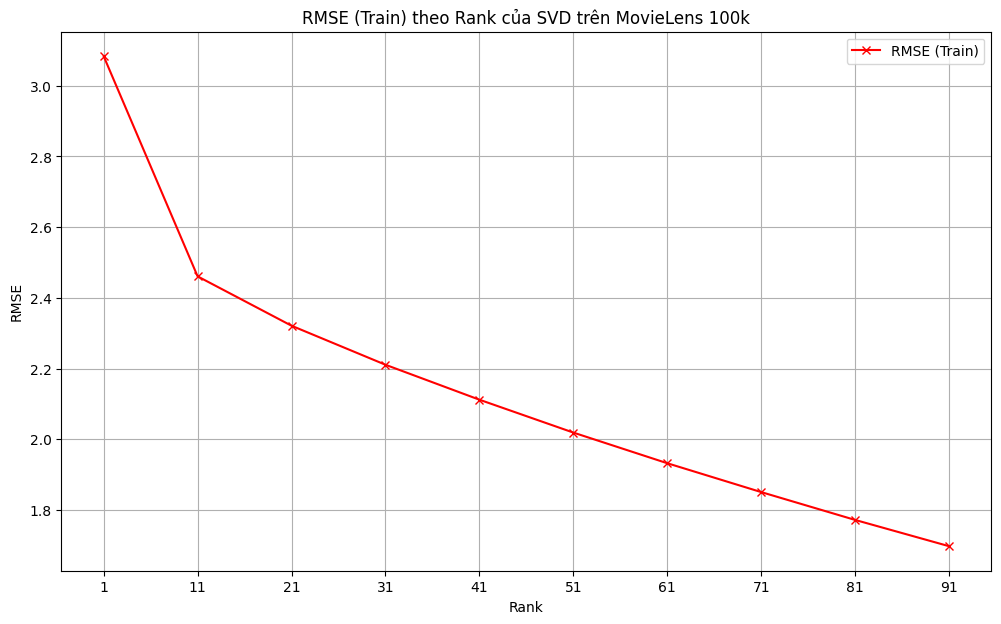

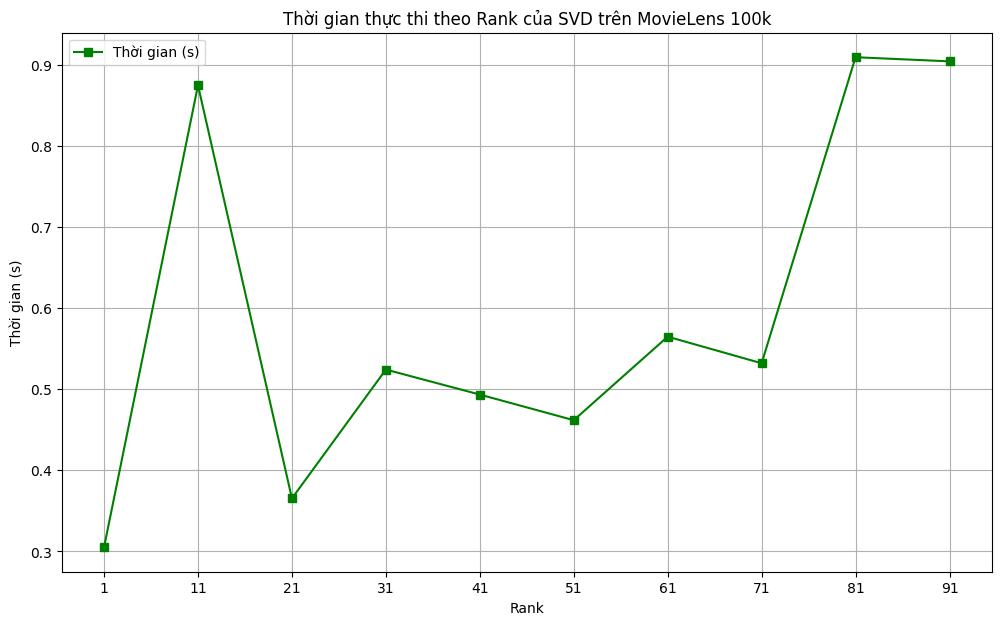

In [11]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ RMSE (Test) theo Rank
fig_test_rmse = plt.figure(figsize=(12, 7))
plt.plot(results_df_movielens['Rank'], results_df_movielens['RMSE (Test)'], marker='o', label='RMSE (Test)')
plt.title('RMSE (Test) theo Rank của SVD trên MovieLens 100k')
plt.xlabel('Rank')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(results_df_movielens['Rank'])
plt.legend()
plt.show()

# Vẽ biểu đồ RMSE (Train) theo Rank
fig_train_rmse = plt.figure(figsize=(12, 7))
plt.plot(results_df_movielens['Rank'], results_df_movielens['RMSE (Train)'], marker='x', color='red', label='RMSE (Train)')
plt.title('RMSE (Train) theo Rank của SVD trên MovieLens 100k')
plt.xlabel('Rank')
plt.ylabel('RMSE')
plt.grid(True)
plt.xticks(results_df_movielens['Rank'])
plt.legend()
plt.show()

# Vẽ biểu đồ Thời gian theo Rank
fig_time = plt.figure(figsize=(12, 7))
plt.plot(results_df_movielens['Rank'], results_df_movielens['Thời gian (s)'], marker='s', color='green', label='Thời gian (s)')
plt.title('Thời gian thực thi theo Rank của SVD trên MovieLens 100k')
plt.xlabel('Rank')
plt.ylabel('Thời gian (s)')
plt.grid(True)
plt.xticks(results_df_movielens['Rank'])
plt.legend()
plt.show()


In [ ]:
def get_real_recommendations(user_id, num_recs=10):
    # Phim đã xem
    user_row_number = user_id # Trong ML-100k, ID bắt đầu từ 1
    sorted_user_predictions = preds_df.loc[user_id].sort_values(ascending=False)

    # Lấy dữ liệu phim đã đánh giá
    user_data = real_df[real_df.user_id == user_id]
    user_full = user_data.merge(movies_df, on='item_id').sort_values(['rating'], ascending=False)

    print(f"User {user_id} đã thích các phim:")
    print(user_full[['movie_title', 'rating']].head(5))

    # Gợi ý phim chưa xem
    recommendations = movies_df[~movies_df['item_id'].isin(user_full['item_id'])]
    recommendations = recommendations.merge(pd.DataFrame(sorted_user_predictions).reset_index(), on='item_id')
    recommendations = recommendations.rename(columns={user_id: 'prediction'}).sort_values('prediction', ascending=False)

    print(f"\nTop {num_recs} phim gợi ý cho User {user_id}:")
    return recommendations.head(num_recs)

# Thử nghiệm với User ID 123
display(get_real_recommendations(user_id=123))